## Genomics

## Sai Gadipati

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

- The MSE is 1.252

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

- The model displays a very low bias as the MSE is very close to 0 which means it memorized the training data almost perfectly. However, the MSE on unseen data is significantly higher and inconsistent, as seen in the histogram. This indicates high variance where the model is overfit in training and often fails to generalize. In terms of the variance bias trade-off, we have minimized bias at the cost of low variability.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

- The model selected a set of 80 genes that had non-zero coefficients. The model discarded 7,049 genes.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

- LASSO is overfitting when the alpha is under 0.000655 and is underfitting when the alpha value is over 0.000655 which indicates that that is the optimal value.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

- Linear regression is perfect on the training set because it overfits data by memorizing noise across all genes which results in a near 0 bias but high variance. LASSO provides better predictions because it discards irrelevant genes, 7,049 in this case, which helps reduce variance and allows for better predictions.

7. Why do regularization methods lend themselves to scenarios like precision health?

- Regularization methods are crucial for precision health because these datasets often have thousands of data points that are all creating "noise." Regularization allows for reduction in the size of these datasets into more manageable ones to isolate for bioligically relevant variables. Therefore, the methods reduce noise and prevent overfitting making the model more accurate and reliable.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

- There are several important risks to keep in mind while using methods like LASSO. One of the primary risks is that LASSO favors statistical correlation over biological causation. Because it tends to select only one gene from a set of highly correlated genes, important disease-driving genes can be ignored, creating omitted variable bias. Furthermore, when the number of genes far exceeds the number of patients, the model becomes unstable and small changes can produce vastly different results. Because these models are used for high importance decisions like surgery or other risky treatments, relying on them for non-causal relationships can have dangerous outcomes.


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path, Lasso, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

import urllib.request
import os
import zipfile
import os

In [9]:
# Part 1
gen_df = pd.read_csv('/content/golub.csv')

mapping = {'allB':0,
          'allT':0,
          'aml':1}

gen_df['target'] = gen_df['cancer'].map(mapping)

OLS training MSE: 1.2522824482837894e-30


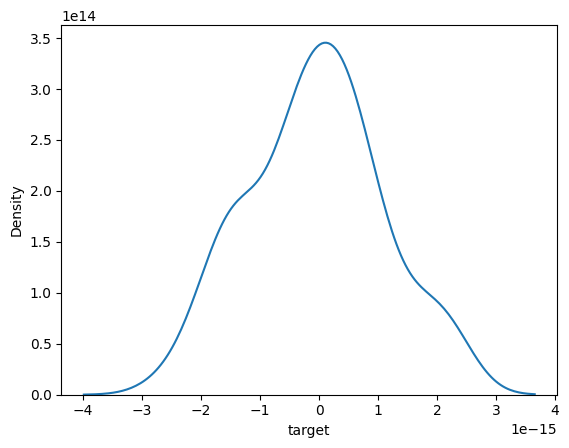

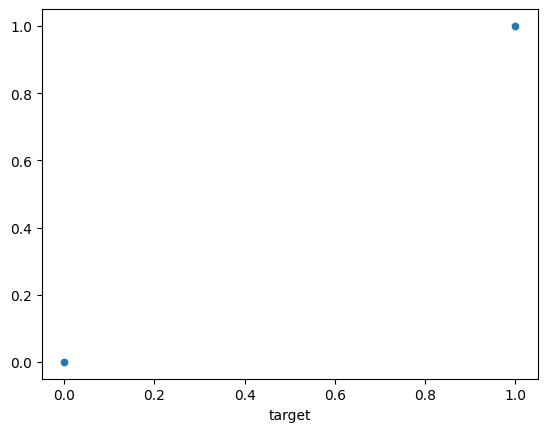

In [10]:
# Part 2

squared_error = lambda true, pred: np.mean((true - pred) ** 2)

# Separate target variable and drop non-feature columns
target = gen_df['target']
features = gen_df.drop(
    ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'target'],
    axis=1
)

# Fit baseline OLS regression
lr = LinearRegression()
fitted_lr = lr.fit(features, target)

predictions_lr = fitted_lr.predict(features)
print(f'OLS training MSE: {squared_error(target, predictions_lr)}')

# Residual distribution
resid = predictions_lr - target
sns.kdeplot(resid)
plt.show()
resid.describe()

sns.scatterplot(x=target, y=predictions_lr)
plt.show()

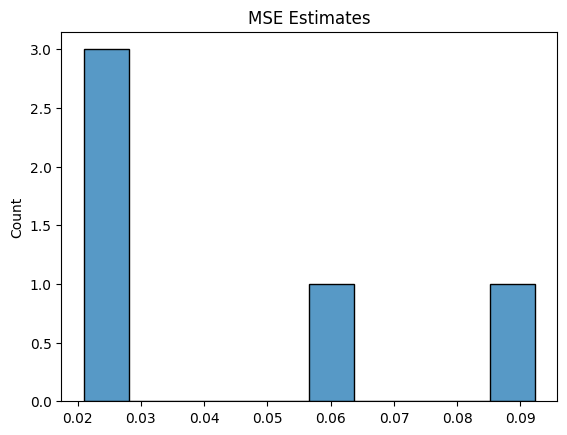

Fold scores: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean score: 0.04336595898622785
Median score: 0.024419803797537328
Std dev: 0.028107820694269984


In [11]:
# Part 3

# Set up and run 5-fold cross-validation
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=100)
cv_results = cross_val_score(
    lr, features, target,
    cv=cv_strategy,
    scoring='neg_mean_squared_error'
)

fold_mse = -cv_results

# Plot distribution of MSE across folds
sns.histplot(fold_mse, bins=10).set(title='MSE Estimates')
plt.show()

print("Fold scores:",  fold_mse)
print("Mean score:",   np.mean(fold_mse))
print("Median score:", np.median(fold_mse))
print("Std dev:",      np.std(fold_mse))


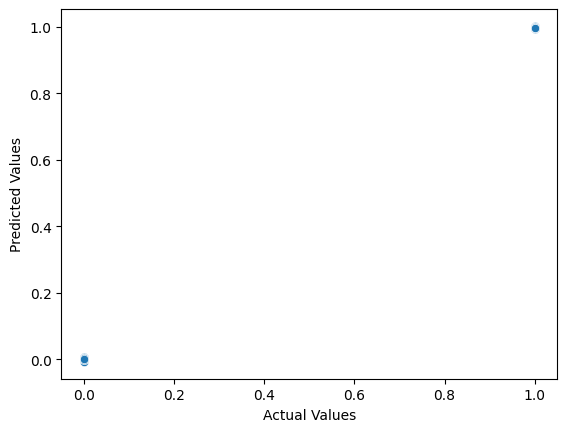

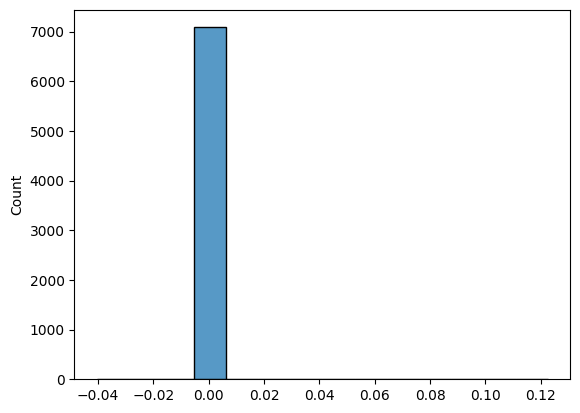

Selected Genes:
 Index(['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at',
       'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at',
       'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at',
       'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M63138_at', 'M84526_at',
       'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at',
       'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at',
       'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at',
       'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at',
       'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at',
       'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at',
       'K02777_s_at',

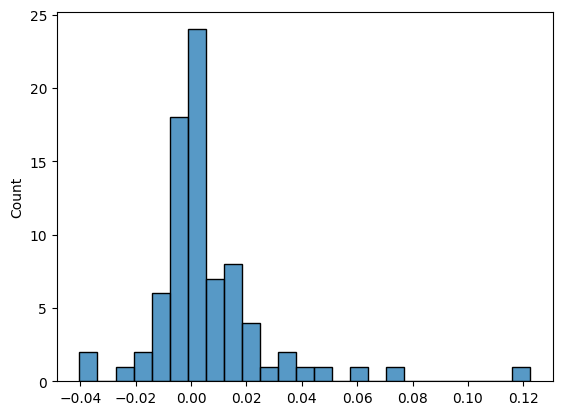

Nonzero coefficients: 80
Total genes: 7129


In [12]:
# 4. Cross-Validated Lasso

normalizer = StandardScaler()
features_scaled = normalizer.fit_transform(features)

# Search over a log-spaced grid of regularization strengths
penalty_grid = np.logspace(-4, -2, num=50)
lasso_cv_model = LassoCV(
    cv=10,
    alphas=penalty_grid,
    random_state=100,
    max_iter=10000
)
lasso_cv_model = lasso_cv_model.fit(features_scaled, target)

best_alpha      = lasso_cv_model.alpha_
best_alpha_idx  = np.argmin(np.mean(lasso_cv_model.mse_path_, axis=1))
best_coefs      = Lasso(alpha=best_alpha, max_iter=10000).fit(features_scaled, target).coef_

# Plot actual LASSO vs. predicted values
final_lasso = Lasso(alpha=best_alpha, max_iter=10000)
final_lasso.fit(features_scaled, target)
lasso_preds = final_lasso.predict(features_scaled)

sns.scatterplot(x=target, y=lasso_preds)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

# Plot histogram of all coefficients
sns.histplot(best_coefs)
plt.show()

# Plot histogram of all non-zero coefficients
active_mask = np.where(best_coefs != 0)
print('Selected Genes:\n', features.columns[active_mask])
sns.histplot(best_coefs[active_mask])
plt.show()

print("Nonzero coefficients:", np.sum(best_coefs != 0))
print("Total genes:",          len(best_coefs))

Optimal cost hyperparameter: 0.0006551285568595509


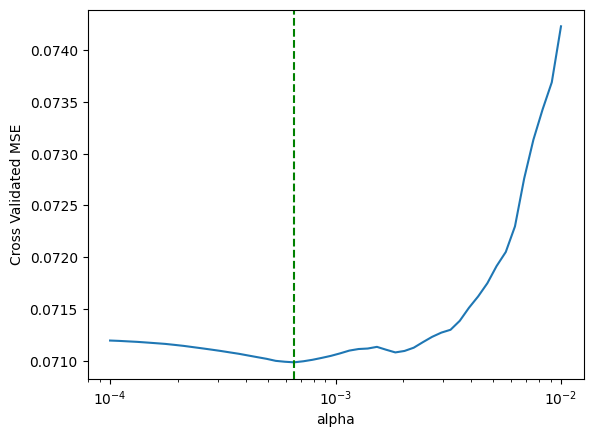

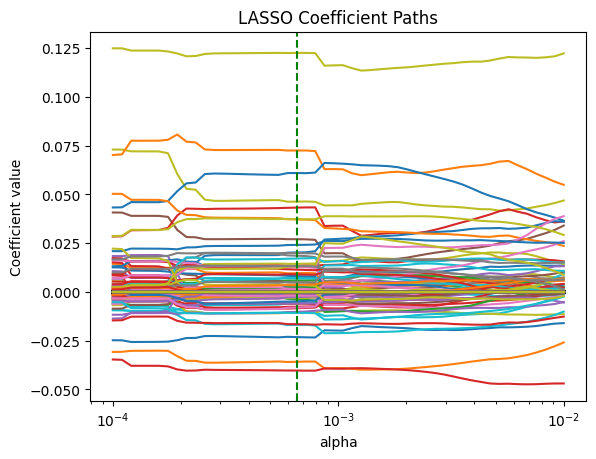

In [14]:
# Part 5

# Cross validated MSE versus alpha
sns.lineplot(x=lasso_cv_model.alphas_, y=np.mean(lasso_cv_model.mse_path_, axis=1))
plt.axvline(x=best_alpha, color='green', linestyle='--', linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {best_alpha}')
plt.show()

# Track and plot coefficient paths as alpha changes
coef_paths = []
for penalty in lasso_cv_model.alphas_:
    reg_step = Lasso(alpha=penalty, max_iter=10_000)
    reg_step = reg_step.fit(features_scaled, target)
    coef_paths.append(reg_step.coef_)
coef_paths = np.array(coef_paths)

plt.figure()
for i in range(coef_paths.shape[1]):
    plt.plot(lasso_cv_model.alphas_, coef_paths[:, i], label=features.columns[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=best_alpha, color='green', linestyle='--')
plt.show()